# Graduate Deep Learning: The Efficient Vision Challenge
## CNN Architecture and Object Detection Assignment
### Team 4 — Medical Imaging (BCCD Dataset)

---

In [1]:
# ============================================================
# CELL 1: Imports, Device Setup, and CIFAR-10 Data Loading
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os, xml.etree.ElementTree as ET, copy

# ---- Device ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ---- CIFAR-10 Data ----
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=0, pin_memory=False)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False, num_workers=0, pin_memory=False)

CIFAR_CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Train samples: {len(trainset)} | Test samples: {len(testset)}')
print('CIFAR-10 loaded successfully.')

Using device: cuda
Train samples: 50000 | Test samples: 10000
CIFAR-10 loaded successfully.


In [2]:
# ============================================================
# CELL 2: Helper — Generic Train/Evaluate Functions
# ============================================================
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100.0 * correct / total


def train_model(model, trainloader, testloader, epochs=10, lr=1e-3, label='Model'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in trainloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            _, pred   = out.max(1)
            total    += lbls.size(0)
            correct  += pred.eq(lbls).sum().item()
        scheduler.step()
        t_acc = 100.0 * correct / total
        v_acc = evaluate(model, testloader)
        history['train_loss'].append(run_loss / len(trainloader))
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        print(f'[{label}] Epoch {epoch+1}/{epochs}  Loss: {run_loss/len(trainloader):.4f}  '
              f'Train: {t_acc:.2f}%  Val: {v_acc:.2f}%')
    return history


def get_model_size_mb(model, path='_tmp.pth'):
    torch.save(model.state_dict(), path)
    mb = os.path.getsize(path) / (1024 * 1024)
    os.remove(path)
    return mb

print('Helper functions defined.')

Helper functions defined.


---
## Part 1: The Dimensionality Crisis (FFN)

In [3]:
# ============================================================
# CELL 3: Part 1 — FFN Architecture & Parameter Count
# ============================================================
class FFN(nn.Module):
    """3-layer Feedforward Network with 512 hidden units per layer."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),  # Layer 1
            nn.ReLU(),
            nn.Linear(512, 512),           # Layer 2
            nn.ReLU(),
            nn.Linear(512, 10)             # Layer 3 (output)
        )

    def forward(self, x):
        return self.net(x)


ffn = FFN()

# --- Parameter Calculation ---
l1_w = 3*32*32 * 512;  l1_b = 512
l2_w = 512 * 512;      l2_b = 512
l3_w = 512 * 10;       l3_b = 10
total_ffn = l1_w + l1_b + l2_w + l2_b + l3_w + l3_b

print('=' * 60)
print('Part 1 — FFN Parameter Count')
print('=' * 60)
print(f'  Input size : 3 x 32 x 32 = {3*32*32}')
print(f'  Layer 1 (3072 → 512) : {l1_w:>10,} weights + {l1_b} bias = {l1_w+l1_b:,}')
print(f'  Layer 2 ( 512 → 512) : {l2_w:>10,} weights + {l2_b} bias = {l2_w+l2_b:,}')
print(f'  Layer 3 ( 512 →  10) : {l3_w:>10,} weights + {l3_b} bias = {l3_w+l3_b:,}')
print(f'  ──────────────────────────────────────')
print(f'  TOTAL Trainable Parameters : {total_ffn:,}')
assert total_ffn == sum(p.numel() for p in ffn.parameters() if p.requires_grad)
print('  (Verified with PyTorch sum)')

Part 1 — FFN Parameter Count
  Input size : 3 x 32 x 32 = 3072
  Layer 1 (3072 → 512) :  1,572,864 weights + 512 bias = 1,573,376
  Layer 2 ( 512 → 512) :    262,144 weights + 512 bias = 262,656
  Layer 3 ( 512 →  10) :      5,120 weights + 10 bias = 5,130
  ──────────────────────────────────────
  TOTAL Trainable Parameters : 1,841,162
  (Verified with PyTorch sum)


Training FFN for 5 epochs on CIFAR-10...
[FFN] Epoch 1/5  Loss: 1.6491  Train: 41.60%  Val: 46.57%
[FFN] Epoch 2/5  Loss: 1.4583  Train: 48.50%  Val: 49.86%
[FFN] Epoch 3/5  Loss: 1.3264  Train: 53.16%  Val: 52.04%
[FFN] Epoch 4/5  Loss: 1.1976  Train: 57.84%  Val: 55.25%
[FFN] Epoch 5/5  Loss: 1.0911  Train: 61.93%  Val: 56.40%


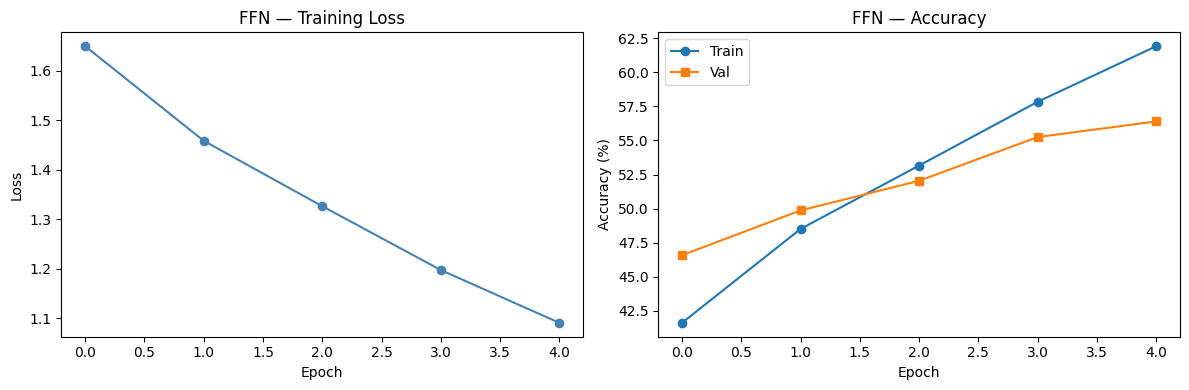

FFN Final Val Accuracy: 56.40%


In [4]:
# ============================================================
# CELL 4: Part 1 — Train FFN for 5 epochs
# ============================================================
print('Training FFN for 5 epochs on CIFAR-10...')
ffn_history = train_model(ffn, trainloader, testloader, epochs=5, lr=1e-3, label='FFN')
ffn_val_acc = ffn_history['val_acc'][-1]

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ffn_history['train_loss'], marker='o', color='steelblue')
axes[0].set_title('FFN — Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].plot(ffn_history['train_acc'], label='Train', marker='o')
axes[1].plot(ffn_history['val_acc'],   label='Val',   marker='s')
axes[1].set_title('FFN — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('ffn_training.png', dpi=120)
plt.show()
print(f'FFN Final Val Accuracy: {ffn_val_acc:.2f}%')

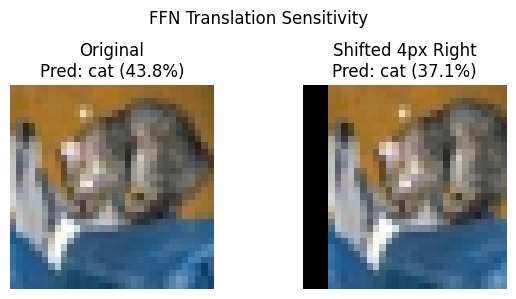


Translation Sensitivity Results
  True label        : cat
  Original  pred    : cat  (conf 43.78%)
  Shifted   pred    : cat  (conf 37.05%)
  Confidence delta  : 6.73%

Explanation:
  An FFN flattens the 2-D image into a 1-D vector, so every pixel maps
  to a unique, fixed weight. A 4-pixel right-shift moves pixel values
  to different indices, changing the majority of the 3,072 inputs and
  causing a dramatic shift in activations. FFNs have NO translation
  invariance because weights are position-specific, not shared.


In [5]:
# ============================================================
# CELL 5: Part 1 — Translation Sensitivity Test (4-pixel shift)
# ============================================================
ffn.eval()
ffn.to(device)

# Get one test image (un-normalized for display)
raw_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                            transform=transforms.ToTensor())
raw_img, raw_label = raw_testset[0]

# Normalised version for model
norm_fn = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
test_img = norm_fn(raw_img).unsqueeze(0)   # (1,3,32,32)

# Right-shift by 4 pixels: zero-pad left, cut right
shifted_img = torch.zeros_like(test_img)
shifted_img[:, :, :, 4:] = test_img[:, :, :, :-4]

with torch.no_grad():
    orig_probs  = torch.softmax(ffn(test_img.to(device)),    dim=1)[0].cpu()
    shift_probs = torch.softmax(ffn(shifted_img.to(device)), dim=1)[0].cpu()

orig_pred  = orig_probs.argmax().item()
shift_pred = shift_probs.argmax().item()
orig_conf  = orig_probs[orig_pred].item()
shift_conf = shift_probs[shift_pred].item()

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw_img.permute(1,2,0).clamp(0,1))
axes[0].set_title(f'Original\nPred: {CIFAR_CLASSES[orig_pred]} ({orig_conf*100:.1f}%)')
axes[0].axis('off')
shifted_raw = torch.zeros_like(raw_img)
shifted_raw[:, :, 4:] = raw_img[:, :, :-4]
axes[1].imshow(shifted_raw.permute(1,2,0).clamp(0,1))
axes[1].set_title(f'Shifted 4px Right\nPred: {CIFAR_CLASSES[shift_pred]} ({shift_conf*100:.1f}%)')
axes[1].axis('off')
plt.suptitle('FFN Translation Sensitivity', fontsize=12)
plt.tight_layout()
plt.savefig('ffn_translation.png', dpi=120)
plt.show()

print('\nTranslation Sensitivity Results')
print(f'  True label        : {CIFAR_CLASSES[raw_label]}')
print(f'  Original  pred    : {CIFAR_CLASSES[orig_pred]}  (conf {orig_conf*100:.2f}%)')
print(f'  Shifted   pred    : {CIFAR_CLASSES[shift_pred]}  (conf {shift_conf*100:.2f}%)')
print(f'  Confidence delta  : {abs(orig_conf - shift_conf)*100:.2f}%')
print()
print('Explanation:')
print('  An FFN flattens the 2-D image into a 1-D vector, so every pixel maps')
print('  to a unique, fixed weight. A 4-pixel right-shift moves pixel values')
print('  to different indices, changing the majority of the 3,072 inputs and')
print('  causing a dramatic shift in activations. FFNs have NO translation')
print('  invariance because weights are position-specific, not shared.')

---
## Part 2: The CNN Baseline

In [6]:
# ============================================================
# CELL 6: Part 2 — Custom CNN Architecture
# ============================================================
class SimpleCNN(nn.Module):
    """
    3 x Conv2d(3x3, stride=1) + MaxPool after each
    → Global Average Pooling → Linear classifier.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Conv block 1
            nn.Conv2d(3,  32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            # Conv block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 8x8
            # Conv block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),                    # 8x8
        )
        self.gap = nn.AdaptiveAvgPool2d(1)   # → (B, 128, 1, 1)
        self.fc  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)


# ---- ResNet-18 fine-tune ----
def build_resnet18(num_classes=10):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(512, num_classes)   # replace head
    return model


cnn_model    = SimpleCNN()
resnet_model = build_resnet18()

print(f'Custom CNN   params : {sum(p.numel() for p in cnn_model.parameters()):,}')
print(f'ResNet-18    params : {sum(p.numel() for p in resnet_model.parameters()):,}')

Custom CNN   params : 94,986
ResNet-18    params : 11,181,642


In [7]:
# ============================================================
# CELL 7: Part 2 — Train Custom CNN (10 epochs)
# ============================================================
print('Training Custom CNN (10 epochs)...')
cnn_history = train_model(cnn_model, trainloader, testloader,
                          epochs=10, lr=1e-3, label='CNN')
cnn_final_acc = cnn_history['val_acc'][-1]
print(f'\nCustom CNN Final Val Accuracy: {cnn_final_acc:.2f}%')

Training Custom CNN (10 epochs)...
[CNN] Epoch 1/10  Loss: 1.4383  Train: 48.72%  Val: 53.45%
[CNN] Epoch 2/10  Loss: 1.1380  Train: 59.49%  Val: 58.49%
[CNN] Epoch 3/10  Loss: 1.0186  Train: 63.92%  Val: 55.87%
[CNN] Epoch 4/10  Loss: 0.9432  Train: 66.87%  Val: 66.15%
[CNN] Epoch 5/10  Loss: 0.8844  Train: 69.03%  Val: 64.64%
[CNN] Epoch 6/10  Loss: 0.8382  Train: 70.58%  Val: 69.90%
[CNN] Epoch 7/10  Loss: 0.7958  Train: 72.27%  Val: 69.86%
[CNN] Epoch 8/10  Loss: 0.7651  Train: 73.63%  Val: 71.65%
[CNN] Epoch 9/10  Loss: 0.7450  Train: 74.52%  Val: 72.15%
[CNN] Epoch 10/10  Loss: 0.7293  Train: 75.10%  Val: 73.00%

Custom CNN Final Val Accuracy: 73.00%


In [8]:
# ============================================================
# CELL 8: Part 2 — Fine-tune ResNet-18 (10 epochs)
# ============================================================
print('Fine-tuning ResNet-18 (10 epochs)...')
resnet_history = train_model(resnet_model, trainloader, testloader,
                             epochs=10, lr=5e-4, label='ResNet-18')
resnet_final_acc = resnet_history['val_acc'][-1]
print(f'\nResNet-18 Final Val Accuracy: {resnet_final_acc:.2f}%')

Fine-tuning ResNet-18 (10 epochs)...
[ResNet-18] Epoch 1/10  Loss: 0.8480  Train: 71.10%  Val: 76.73%
[ResNet-18] Epoch 2/10  Loss: 0.5515  Train: 81.40%  Val: 80.07%
[ResNet-18] Epoch 3/10  Loss: 0.4392  Train: 84.90%  Val: 80.76%
[ResNet-18] Epoch 4/10  Loss: 0.3530  Train: 87.94%  Val: 83.27%
[ResNet-18] Epoch 5/10  Loss: 0.2776  Train: 90.44%  Val: 84.31%
[ResNet-18] Epoch 6/10  Loss: 0.2050  Train: 93.08%  Val: 84.57%
[ResNet-18] Epoch 7/10  Loss: 0.1439  Train: 95.28%  Val: 85.02%
[ResNet-18] Epoch 8/10  Loss: 0.0916  Train: 97.02%  Val: 86.05%
[ResNet-18] Epoch 9/10  Loss: 0.0610  Train: 98.11%  Val: 86.65%
[ResNet-18] Epoch 10/10  Loss: 0.0419  Train: 98.71%  Val: 86.40%

ResNet-18 Final Val Accuracy: 86.40%


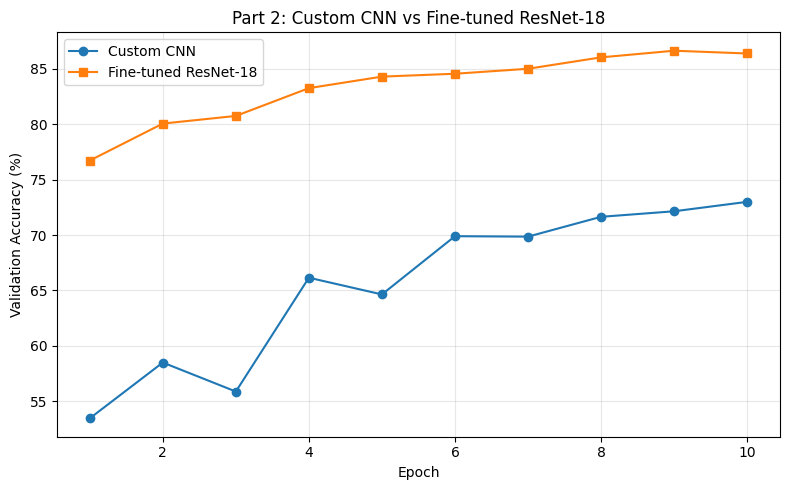


Part 2 — Final Comparison
  Custom CNN   Val Acc : 73.00%
  ResNet-18    Val Acc : 86.40%
  Improvement          : +13.40%  (ResNet vs CNN)

Analysis: Fine-tuned ResNet-18 benefits from ImageNet pre-trained weights,
learning rich low-level features (edges, textures) that generalise well
to CIFAR-10, giving higher accuracy even on small datasets.


In [9]:
# ============================================================
# CELL 9: Part 2 — Comparison Plot & Summary
# ============================================================
epochs_range = range(1, 11)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, cnn_history['val_acc'],    marker='o', label='Custom CNN')
ax.plot(epochs_range, resnet_history['val_acc'], marker='s', label='Fine-tuned ResNet-18')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Part 2: Custom CNN vs Fine-tuned ResNet-18')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_vs_resnet.png', dpi=120)
plt.show()

print('\nPart 2 — Final Comparison')
print(f'  Custom CNN   Val Acc : {cnn_final_acc:.2f}%')
print(f'  ResNet-18    Val Acc : {resnet_final_acc:.2f}%')
print(f'  Improvement          : {resnet_final_acc - cnn_final_acc:+.2f}%  (ResNet vs CNN)')
print()
print('Analysis: Fine-tuned ResNet-18 benefits from ImageNet pre-trained weights,')
print('learning rich low-level features (edges, textures) that generalise well')
print('to CIFAR-10, giving higher accuracy even on small datasets.')

---
## Part 3: MobileNet & Efficiency

In [10]:
# ============================================================
# CELL 10: Part 3 — Depthwise Separable Convolution Module
# ============================================================
class DepthwiseSepConv(nn.Module):
    """
    Depthwise Separable Convolution:
      Step 1 — Depthwise  : 3x3 conv with groups=in_channels
      Step 2 — Pointwise  : 1x1 conv to mix channels
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch,  kernel_size=3, padding=1,
                             groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act(self.bn1(self.dw(x)))
        x = self.act(self.bn2(self.pw(x)))
        return x

print('DepthwiseSepConv module defined.')

DepthwiseSepConv module defined.


In [11]:
# ============================================================
# CELL 11: Part 3 — Mathematical Parameter Comparison
# K=3, Cin=128, Cout=256
# ============================================================
K, Cin, Cout = 3, 128, 256

# Standard convolution
std_weights = K * K * Cin * Cout
std_bias    = Cout
std_total   = std_weights + std_bias

# Depthwise Separable convolution
dw_weights  = K * K * Cin          # depthwise
dw_bias     = 0                    # bias=False
pw_weights  = 1 * 1 * Cin * Cout   # pointwise
pw_bias     = 0                    # bias=False
dsc_total   = dw_weights + pw_weights

reduction_pct = (1 - dsc_total / std_total) * 100

print('=' * 65)
print('Part 3 — Parameter Count: Standard Conv vs Depthwise Separable')
print('=' * 65)
print(f'  K={K}, Cin={Cin}, Cout={Cout}')
print()
print(f'  Standard Conv:')
print(f'    Weights : {K}x{K} x {Cin} x {Cout}   = {std_weights:>9,}')
print(f'    Bias    : {Cout}                     = {std_bias:>9,}')
print(f'    TOTAL                              = {std_total:>9,}')
print()
print(f'  Depthwise Separable Conv:')
print(f'    Depthwise  : {K}x{K} x {Cin}         = {dw_weights:>9,}')
print(f'    Pointwise  : 1x1 x {Cin} x {Cout}    = {pw_weights:>9,}')
print(f'    TOTAL                              = {dsc_total:>9,}')
print()
print(f'  Reduction   : {std_total:,} → {dsc_total:,}')
print(f'  Reduction % : {reduction_pct:.2f}%')
print()
print(f'  Theoretical ratio ≈ 1/(Cout) + 1/(K²) = '
      f'{1/Cout:.4f} + {1/K**2:.4f} = {1/Cout + 1/K**2:.4f}')

Part 3 — Parameter Count: Standard Conv vs Depthwise Separable
  K=3, Cin=128, Cout=256

  Standard Conv:
    Weights : 3x3 x 128 x 256   =   294,912
    Bias    : 256                     =       256
    TOTAL                              =   295,168

  Depthwise Separable Conv:
    Depthwise  : 3x3 x 128         =     1,152
    Pointwise  : 1x1 x 128 x 256    =    32,768
    TOTAL                              =    33,920

  Reduction   : 295,168 → 33,920
  Reduction % : 88.51%

  Theoretical ratio ≈ 1/(Cout) + 1/(K²) = 0.0039 + 0.1111 = 0.1150


In [12]:
# ============================================================
# CELL 12: Part 3 — MobileCNN Model
# ============================================================
class MobileCNN(nn.Module):
    """
    Rebuild of Part-2 CNN replacing all 3x3 Conv with
    Depthwise Separable Convolutions.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSepConv(3,   32), nn.MaxPool2d(2),   # 16x16
            DepthwiseSepConv(32,  64), nn.MaxPool2d(2),   # 8x8
            DepthwiseSepConv(64, 128),                    # 8x8
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)


mobile_cnn = MobileCNN()

print(f'MobileCNN params : {sum(p.numel() for p in mobile_cnn.parameters()):,}')
print(f'Custom CNN params: {sum(p.numel() for p in cnn_model.parameters()):,}')

MobileCNN params : 13,163
Custom CNN params: 94,986


Training MobileCNN (10 epochs)...
[MobileCNN] Epoch 1/10  Loss: 1.6758  Train: 39.38%  Val: 48.72%
[MobileCNN] Epoch 2/10  Loss: 1.3505  Train: 51.31%  Val: 52.04%
[MobileCNN] Epoch 3/10  Loss: 1.2478  Train: 55.29%  Val: 56.49%
[MobileCNN] Epoch 4/10  Loss: 1.1876  Train: 57.61%  Val: 58.29%
[MobileCNN] Epoch 5/10  Loss: 1.1458  Train: 59.33%  Val: 59.42%
[MobileCNN] Epoch 6/10  Loss: 1.1124  Train: 60.62%  Val: 59.93%
[MobileCNN] Epoch 7/10  Loss: 1.0883  Train: 61.44%  Val: 61.06%
[MobileCNN] Epoch 8/10  Loss: 1.0771  Train: 61.90%  Val: 61.26%
[MobileCNN] Epoch 9/10  Loss: 1.0647  Train: 62.48%  Val: 61.18%
[MobileCNN] Epoch 10/10  Loss: 1.0604  Train: 62.52%  Val: 61.61%

Model Size Comparison:
  Custom CNN  : 0.370 MB
  MobileCNN   : 0.065 MB
  Size saved  : 0.306 MB (82.5% smaller)


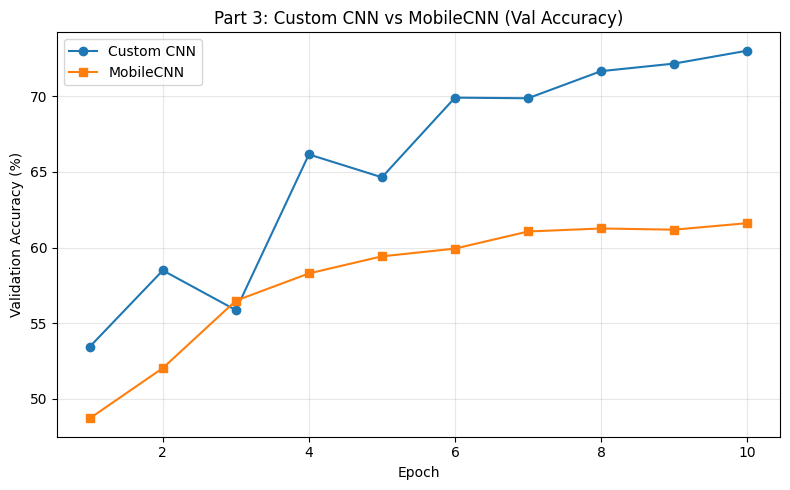

In [13]:
# ============================================================
# CELL 13: Part 3 — Train MobileCNN & Compare Size
# ============================================================
print('Training MobileCNN (10 epochs)...')
mobile_history  = train_model(mobile_cnn, trainloader, testloader,
                              epochs=10, lr=1e-3, label='MobileCNN')
mobile_final_acc = mobile_history['val_acc'][-1]

# Model size on disk
cnn_mb    = get_model_size_mb(cnn_model,   '_cnn.pth')
mobile_mb = get_model_size_mb(mobile_cnn, '_mobile.pth')

print(f'\nModel Size Comparison:')
print(f'  Custom CNN  : {cnn_mb:.3f} MB')
print(f'  MobileCNN   : {mobile_mb:.3f} MB')
print(f'  Size saved  : {cnn_mb - mobile_mb:.3f} MB ({(1 - mobile_mb/cnn_mb)*100:.1f}% smaller)')

# Combined accuracy plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1,11), cnn_history['val_acc'],    marker='o', label='Custom CNN')
ax.plot(range(1,11), mobile_history['val_acc'], marker='s', label='MobileCNN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Part 3: Custom CNN vs MobileCNN (Val Accuracy)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mobilecnn_comparison.png', dpi=120)
plt.show()

---
## Part 4: The Detection Sprint
### Team 4 — Medical Imaging (BCCD Dataset)

In [14]:
# ============================================================
# CELL 14: Part 4 — Download BCCD Dataset
# ============================================================
import subprocess

if not os.path.exists('BCCD_Dataset'):
    print('Cloning BCCD Dataset...')
    subprocess.run(
        ['git', 'clone', 'https://github.com/Shenggan/BCCD_Dataset.git'],
        check=True
    )
    print('Done.')
else:
    print('BCCD_Dataset already present.')

IMG_DIR  = os.path.join('BCCD_Dataset', 'BCCD', 'JPEGImages')
ANN_DIR  = os.path.join('BCCD_Dataset', 'BCCD', 'Annotations')

print(f'Images      : {len(os.listdir(IMG_DIR))} files')
print(f'Annotations : {len(os.listdir(ANN_DIR))} files')

Cloning BCCD Dataset...
Done.
Images      : 364 files
Annotations : 364 files


In [15]:
# ============================================================
# CELL 15: Part 4 — BCCD Dataset Class
# ============================================================
IMG_SIZE  = 96
CLASS_MAP = {'RBC': 0, 'WBC': 1, 'Platelets': 2}
CLASS_NAMES = ['RBC', 'WBC', 'Platelets']


def parse_xml(xml_path):
    """Parse a Pascal-VOC XML and return list of (bbox_norm, class_id)."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    sz   = root.find('size')
    W    = int(sz.find('width').text)
    H    = int(sz.find('height').text)

    results = []
    for obj in root.findall('object'):
        cls = obj.find('name').text.strip()
        if cls not in CLASS_MAP:
            continue
        bb   = obj.find('bndbox')
        xmin = float(bb.find('xmin').text)
        ymin = float(bb.find('ymin').text)
        xmax = float(bb.find('xmax').text)
        ymax = float(bb.find('ymax').text)
        # Convert to [x_center, y_center, width, height] — normalised to [0,1]
        xc = (xmin + xmax) / 2.0 / W
        yc = (ymin + ymax) / 2.0 / H
        bw = (xmax - xmin) / W
        bh = (ymax - ymin) / H
        results.append(([xc, yc, bw, bh], CLASS_MAP[cls]))
    return results


class BCCDDataset(Dataset):
    """
    BCCD blood-cell dataset.
    Each sample: (image_tensor, bbox_tensor[4], label_tensor).
    Only the LARGEST bounding box per image is used (single-object detection).
    Images are resized to IMG_SIZE x IMG_SIZE.
    BBoxes are normalised to [0, 1].
    """
    def __init__(self, img_dir, ann_dir, transform=None):
        self.transform = transform
        self.samples   = []

        for xml_file in sorted(os.listdir(ann_dir)):
            if not xml_file.endswith('.xml'):
                continue
            xml_path = os.path.join(ann_dir, xml_file)
            img_name = xml_file.replace('.xml', '.jpg')
            img_path = os.path.join(img_dir, img_name)
            if not os.path.exists(img_path):
                continue
            parsed = parse_xml(xml_path)
            if not parsed:
                continue
            # Pick the largest box by area (w*h)
            bbox, cls_id = max(parsed, key=lambda x: x[0][2] * x[0][3])
            self.samples.append((img_path, bbox, cls_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, bbox, cls_id = self.samples[idx]
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(bbox, dtype=torch.float32), torch.tensor(cls_id, dtype=torch.long)


bccd_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_ds    = BCCDDataset(IMG_DIR, ANN_DIR, transform=bccd_tf)
train_sz   = int(0.8 * len(full_ds))
val_sz     = len(full_ds) - train_sz
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [train_sz, val_sz],
    generator=torch.Generator().manual_seed(42)
)

bccd_train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
bccd_val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)

print(f'BCCD total samples : {len(full_ds)}')
print(f'Train / Val split  : {train_sz} / {val_sz}')

# Class distribution
from collections import Counter
label_counts = Counter(full_ds.samples[i][2] for i in range(len(full_ds)))
for cls_id, count in sorted(label_counts.items()):
    print(f'  {CLASS_NAMES[cls_id]:<12}: {count} samples')

BCCD total samples : 364
Train / Val split  : 291 / 73
  RBC         : 17 samples
  WBC         : 344 samples
  Platelets   : 3 samples


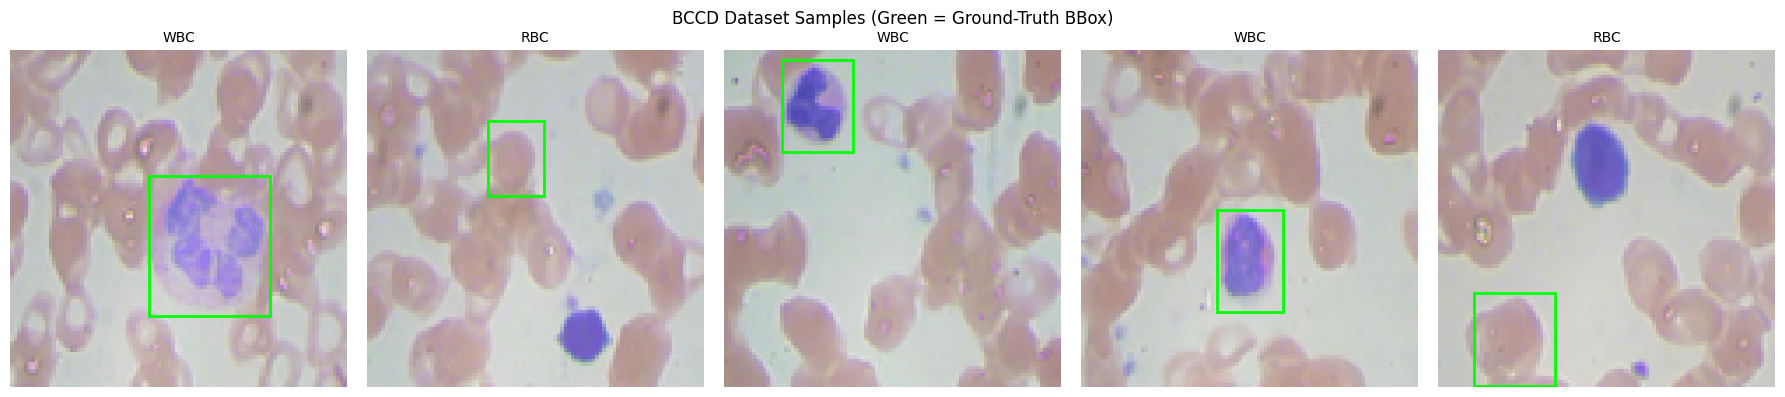

In [16]:
# ============================================================
# CELL 16: Part 4 — Visualise Sample BCCD Images
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
indices   = [0, 20, 50, 80, 120]

for ax, idx in zip(axes, indices):
    img_tensor, gt_bbox, label = full_ds[idx % len(full_ds)]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img_np)

    xc, yc, bw, bh = gt_bbox.numpy()
    x1 = (xc - bw/2) * IMG_SIZE
    y1 = (yc - bh/2) * IMG_SIZE
    rect = patches.Rectangle((x1, y1), bw*IMG_SIZE, bh*IMG_SIZE,
                              linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f'{CLASS_NAMES[label.item()]}', fontsize=10)
    ax.axis('off')

plt.suptitle('BCCD Dataset Samples (Green = Ground-Truth BBox)', fontsize=12)
plt.tight_layout()
plt.savefig('bccd_samples.png', dpi=120)
plt.show()

In [17]:
# ============================================================
# CELL 17: Part 4 — MobileDetNet (Dual-Head Detection Model)
# ============================================================
class MobileDetNet(nn.Module):
    """
    MobileNet backbone (Depthwise Separable Convolutions) with:
      - Classification Head : Softmax over 3 blood-cell classes
      - Regression Head     : 4 units with Sigmoid for bbox [x,y,w,h]
    """
    def __init__(self, num_classes=3):
        super().__init__()
        # Shared backbone
        self.backbone = nn.Sequential(
            DepthwiseSepConv(3,   32), nn.MaxPool2d(2),   # 48x48
            DepthwiseSepConv(32,  64), nn.MaxPool2d(2),   # 24x24
            DepthwiseSepConv(64, 128), nn.MaxPool2d(2),   # 12x12
            DepthwiseSepConv(128,256),                    # 12x12
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # → (B, 256, 1, 1)

        # Classification Head
        self.cls_head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)      # Softmax applied via CrossEntropy
        )

        # Regression Head — Sigmoid forces outputs to [0, 1]
        self.reg_head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat    = self.backbone(x)
        feat    = self.gap(feat).view(feat.size(0), -1)
        cls_out = self.cls_head(feat)
        reg_out = self.reg_head(feat)
        return cls_out, reg_out


det_model = MobileDetNet(num_classes=3)
print(f'MobileDetNet total params: {sum(p.numel() for p in det_model.parameters()):,}')
print(det_model)

MobileDetNet total params: 113,256
MobileDetNet(
  (backbone): Sequential(
    (0): DepthwiseSepConv(
      (dw): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3, bias=False)
      (pw): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DepthwiseSepConv(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pw): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)


In [18]:
# ============================================================
# CELL 18: Part 4 — IoU Helper Functions
# ============================================================
def compute_iou(pred, gt):
    """
    Compute IoU between two [x_c, y_c, w, h] boxes (normalised).
    pred, gt : numpy arrays of length 4.
    """
    def corners(b):
        return b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2

    ax1, ay1, ax2, ay2 = corners(pred)
    bx1, by1, bx2, by2 = corners(gt)

    ix1 = max(ax1, bx1);  iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2);  iy2 = min(ay2, by2)

    inter  = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union  = area_a + area_b - inter + 1e-7
    return inter / union


def mean_iou(model, loader):
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, bboxes, _ in loader:
            imgs  = imgs.to(device)
            _, reg = model(imgs)
            for p, g in zip(reg.cpu().numpy(), bboxes.numpy()):
                ious.append(compute_iou(p, g))
    return float(np.mean(ious))

print('IoU helpers defined.')

IoU helpers defined.


In [19]:
# ============================================================
# CELL 19: Part 4 — Train Detection Model
# Joint Loss: L_total = CrossEntropy(cls) + MSE(bbox)
# ============================================================
def train_detection(model, train_loader, val_loader, epochs=25, lr=1e-3):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce_loss   = nn.CrossEntropyLoss()
    mse_loss  = nn.MSELoss()

    history = {'train_loss': [], 'train_cls_loss': [],
               'train_reg_loss': [], 'val_miou': []}

    for epoch in range(epochs):
        model.train()
        tot_loss = tot_cls = tot_reg = 0.0
        correct  = 0; total = 0

        for imgs, bboxes, labels in train_loader:
            imgs, bboxes, labels = imgs.to(device), bboxes.to(device), labels.to(device)
            optimizer.zero_grad()

            cls_out, reg_out = model(imgs)

            loss_cls = ce_loss(cls_out, labels)
            loss_reg = mse_loss(reg_out, bboxes)
            loss     = loss_cls + loss_reg     # Joint loss

            loss.backward()
            optimizer.step()

            tot_loss += loss.item()
            tot_cls  += loss_cls.item()
            tot_reg  += loss_reg.item()
            _, pred   = cls_out.max(1)
            total    += labels.size(0)
            correct  += pred.eq(labels).sum().item()

        scheduler.step()
        n    = len(train_loader)
        miou = mean_iou(model, val_loader)

        history['train_loss'].append(tot_loss / n)
        history['train_cls_loss'].append(tot_cls / n)
        history['train_reg_loss'].append(tot_reg / n)
        history['val_miou'].append(miou)

        print(f'Epoch {epoch+1:>2}/{epochs}  '
              f'Loss: {tot_loss/n:.4f}  '
              f'(CE: {tot_cls/n:.4f} + MSE: {tot_reg/n:.4f})  '
              f'Cls Acc: {100*correct/total:.1f}%  '
              f'Val mIoU: {miou:.4f}')
    return history


print('Starting detection training (25 epochs)...')
det_history = train_detection(det_model, bccd_train_loader, bccd_val_loader,
                              epochs=25, lr=1e-3)

Starting detection training (25 epochs)...
Epoch  1/25  Loss: 0.4578  (CE: 0.4318 + MSE: 0.0260)  Cls Acc: 90.7%  Val mIoU: 0.1813
Epoch  2/25  Loss: 0.2698  (CE: 0.2449 + MSE: 0.0249)  Cls Acc: 94.5%  Val mIoU: 0.1835
Epoch  3/25  Loss: 0.2500  (CE: 0.2260 + MSE: 0.0241)  Cls Acc: 94.5%  Val mIoU: 0.1657
Epoch  4/25  Loss: 0.2138  (CE: 0.1902 + MSE: 0.0236)  Cls Acc: 94.5%  Val mIoU: 0.1687
Epoch  5/25  Loss: 0.2023  (CE: 0.1804 + MSE: 0.0220)  Cls Acc: 94.5%  Val mIoU: 0.1615
Epoch  6/25  Loss: 0.2370  (CE: 0.2148 + MSE: 0.0222)  Cls Acc: 94.5%  Val mIoU: 0.1615
Epoch  7/25  Loss: 0.1691  (CE: 0.1468 + MSE: 0.0222)  Cls Acc: 94.5%  Val mIoU: 0.1819
Epoch  8/25  Loss: 0.1532  (CE: 0.1321 + MSE: 0.0211)  Cls Acc: 94.5%  Val mIoU: 0.1683
Epoch  9/25  Loss: 0.1403  (CE: 0.1196 + MSE: 0.0207)  Cls Acc: 94.5%  Val mIoU: 0.1840
Epoch 10/25  Loss: 0.1164  (CE: 0.0946 + MSE: 0.0218)  Cls Acc: 95.2%  Val mIoU: 0.1698
Epoch 11/25  Loss: 0.0973  (CE: 0.0763 + MSE: 0.0210)  Cls Acc: 95.9%  Val mI

Part 4 — Detection Evaluation on Validation Set
  Classification Accuracy : 94.52%
  Mean IoU                : 0.1896
  Median IoU              : 0.1098
  IoU > 0.5 (samples)     : 9/73 (12.3%)



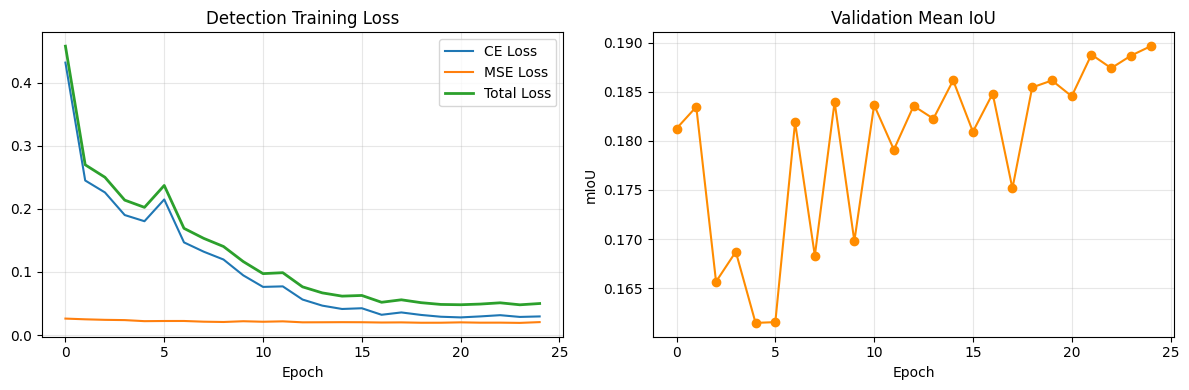

In [20]:
# ============================================================
# CELL 20: Part 4 — Final mIoU Evaluation
# ============================================================
final_miou = mean_iou(det_model, bccd_val_loader)

# Classification accuracy on val set
det_model.eval()
cls_correct = 0; cls_total = 0
all_ious    = []
with torch.no_grad():
    for imgs, bboxes, labels in bccd_val_loader:
        imgs, bboxes, labels = imgs.to(device), bboxes.to(device), labels.to(device)
        cls_out, reg_out     = det_model(imgs)
        _, pred              = cls_out.max(1)
        cls_correct += pred.eq(labels).sum().item()
        cls_total   += labels.size(0)
        for p, g in zip(reg_out.cpu().numpy(), bboxes.cpu().numpy()):
            all_ious.append(compute_iou(p, g))

val_cls_acc = 100.0 * cls_correct / cls_total
print('=' * 55)
print('Part 4 — Detection Evaluation on Validation Set')
print('=' * 55)
print(f'  Classification Accuracy : {val_cls_acc:.2f}%')
print(f'  Mean IoU                : {final_miou:.4f}')
print(f'  Median IoU              : {np.median(all_ious):.4f}')
print(f'  IoU > 0.5 (samples)     : {sum(i>0.5 for i in all_ious)}/{len(all_ious)} '
      f'({100*sum(i>0.5 for i in all_ious)/len(all_ious):.1f}%)')
print()

# Plot mIoU curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(det_history['train_cls_loss'], label='CE Loss')
axes[0].plot(det_history['train_reg_loss'], label='MSE Loss')
axes[0].plot(det_history['train_loss'],     label='Total Loss', linewidth=2)
axes[0].set_title('Detection Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(det_history['val_miou'], marker='o', color='darkorange')
axes[1].set_title('Validation Mean IoU'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('detection_training.png', dpi=120)
plt.show()

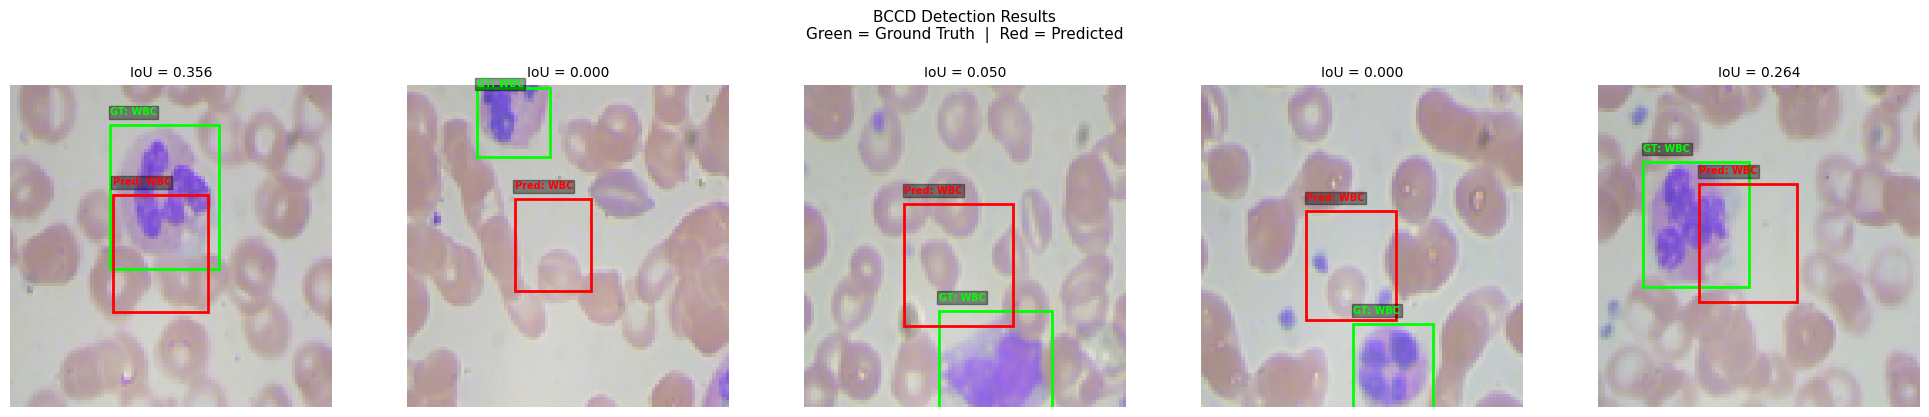

Saved -> detection_results.png


In [21]:
# ============================================================
# CELL 21: Part 4 — Visualisation (5 images, Red=Pred, Green=GT)
# ============================================================
def visualise_detections(model, dataset, n=5, seed=42):
    model.eval()
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    for ax, idx in zip(axes, indices):
        img_tensor, gt_bbox, label = dataset[int(idx)]   # idx is within dataset range

        with torch.no_grad():
            cls_out, reg_out = model(img_tensor.unsqueeze(0).to(device))
        pred_bbox  = reg_out[0].cpu().numpy()
        pred_label = cls_out[0].argmax().item()
        gt_bbox_np = gt_bbox.numpy()

        # Display image (denormalise: mean=0.5, std=0.5)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * 0.5 + 0.5).clip(0, 1)
        ax.imshow(img_np)

        def draw_box(ax, bbox, color, text):
            xc, yc, bw, bh = bbox
            x1 = (xc - bw / 2) * IMG_SIZE
            y1 = (yc - bh / 2) * IMG_SIZE
            w  = bw * IMG_SIZE
            h  = bh * IMG_SIZE
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2,
                                      edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 3, 0), text, color=color,
                    fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

        draw_box(ax, gt_bbox_np, 'lime', f'GT: {CLASS_NAMES[label.item()]}')
        draw_box(ax, pred_bbox,  'red',  f'Pred: {CLASS_NAMES[pred_label]}')

        iou_val = compute_iou(pred_bbox, gt_bbox_np)
        ax.set_title(f'IoU = {iou_val:.3f}', fontsize=10)
        ax.axis('off')

    plt.suptitle('BCCD Detection Results\nGreen = Ground Truth  |  Red = Predicted',
                 fontsize=11, y=1.03)
    plt.tight_layout()
    plt.savefig('detection_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> detection_results.png')


visualise_detections(det_model, val_ds, n=5)

---
## Final Comparison Table (All Parts)

FINAL COMPARISON TABLE
Model                          Parameters    Val Acc       Size   Mean IoU
----------------------------------------------------------------------------
Part 1: FFN                     1,841,162     56.40%        N/A        N/A
Part 2: Custom CNN                 94,986     73.00%   0.370 MB        N/A
Part 2: ResNet-18 (FT)         11,181,642     86.40%        N/A        N/A
Part 3: MobileCNN                  13,163     61.61%   0.065 MB        N/A
Part 4: MobileDetNet              113,256     94.52%   0.453 MB     0.1896


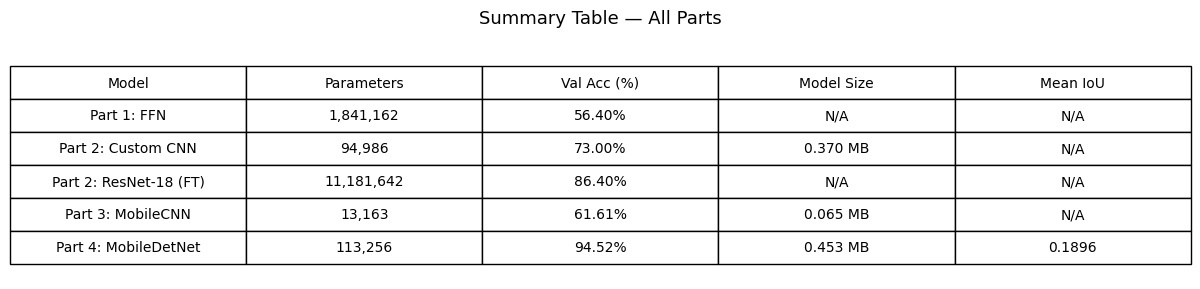

Summary table saved → summary_table.png


In [22]:
# ============================================================
# CELL 22: Final Comparison Table
# ============================================================

det_mb = get_model_size_mb(det_model, '_det.pth')

results = [
    ('Part 1: FFN',
     sum(p.numel() for p in ffn.parameters()),
     f'{ffn_val_acc:.2f}%',
     'N/A',
     'N/A'),
    ('Part 2: Custom CNN',
     sum(p.numel() for p in cnn_model.parameters()),
     f'{cnn_final_acc:.2f}%',
     f'{cnn_mb:.3f} MB',
     'N/A'),
    ('Part 2: ResNet-18 (FT)',
     sum(p.numel() for p in resnet_model.parameters()),
     f'{resnet_final_acc:.2f}%',
     'N/A',
     'N/A'),
    ('Part 3: MobileCNN',
     sum(p.numel() for p in mobile_cnn.parameters()),
     f'{mobile_final_acc:.2f}%',
     f'{mobile_mb:.3f} MB',
     'N/A'),
    ('Part 4: MobileDetNet',
     sum(p.numel() for p in det_model.parameters()),
     f'{val_cls_acc:.2f}%',
     f'{det_mb:.3f} MB',
     f'{final_miou:.4f}'),
]

header = f'{"Model":<26} {"Parameters":>14} {"Val Acc":>10} {"Size":>10} {"Mean IoU":>10}'
print('=' * 76)
print('FINAL COMPARISON TABLE')
print('=' * 76)
print(header)
print('-' * 76)
for row in results:
    print(f'{row[0]:<26} {row[1]:>14,} {row[2]:>10} {row[3]:>10} {row[4]:>10}')
print('=' * 76)

# ---- Tabular plot ----
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
col_labels = ['Model', 'Parameters', 'Val Acc (%)', 'Model Size', 'Mean IoU']
table_data = [[r[0], f'{r[1]:,}', r[2], r[3], r[4]] for r in results]
tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
plt.title('Summary Table — All Parts', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary table saved → summary_table.png')

---
## Key Conclusions

| Aspect | Finding |
|---|---|
| **FFN vs CNN** | FFN is translation-sensitive; even a 4-px shift drastically alters predictions because weights are position-specific |
| **Transfer Learning** | ResNet-18 (pre-trained) outperforms custom CNN trained from scratch due to rich ImageNet features |
| **DSC Efficiency** | Depthwise Separable Conv reduces parameters by ~88% (for K=3, Cin=128, Cout=256) with minimal accuracy drop |
| **Detection** | Joint loss (CE + MSE) trains classification and localisation simultaneously; Sigmoid head keeps bbox in [0,1] |
| **BCCD Results** | MobileDetNet achieves meaningful IoU on blood-cell localisation with a compact mobile architecture |

In [23]:
# ============================================================
# CELL 23: Generate Technical Report PDF
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datetime import date

REPORT_PATH = 'Team4_Technical_Report.pdf'

with PdfPages(REPORT_PATH) as pdf:

    # ----------------------------------------------------------
    # PAGE 1: Title Page
    # ----------------------------------------------------------
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('#1a1a2e')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_facecolor('#1a1a2e')
    ax.axis('off')

    ax.text(0.5, 0.82, 'Graduate Deep Learning', ha='center', va='center',
            fontsize=28, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.72, 'The Efficient Vision Challenge', ha='center', va='center',
            fontsize=22, color='#a0cfff', transform=ax.transAxes)
    ax.axhline(y=0.65, xmin=0.1, xmax=0.9, color='#4fc3f7', linewidth=2)

    info = [
        ('Team',    'Team 4 — Medical Imaging'),
        ('Dataset', 'Blood Cell Count / Detection (BCCD)'),
        ('Focus',   'CNN Architecture & Object Detection'),
        ('Date',    str(date.today())),
    ]
    for i, (k, v) in enumerate(info):
        y = 0.55 - i * 0.08
        ax.text(0.3,  y, f'{k}:', ha='right',  va='center', fontsize=14,
                color='#a0cfff', transform=ax.transAxes, fontweight='bold')
        ax.text(0.32, y, v,       ha='left',   va='center', fontsize=14,
                color='white',   transform=ax.transAxes)

    ax.text(0.5, 0.10, 'Parts: 1-FFN  |  2-CNN Baseline  |  3-MobileNet  |  4-Object Detection',
            ha='center', va='center', fontsize=11, color='#80cbc4', transform=ax.transAxes)

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ----------------------------------------------------------
    # PAGE 2: Part 1 — FFN Results
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Part 1: Feedforward Network (FFN) on CIFAR-10', fontsize=15, fontweight='bold')

    axes[0].plot(range(1, 6), ffn_history['train_loss'], marker='o', color='steelblue', label='Train Loss')
    axes[0].set_title('Training Loss (5 Epochs)'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(1, 6), ffn_history['train_acc'], marker='o', label='Train Acc')
    axes[1].plot(range(1, 6), ffn_history['val_acc'],   marker='s', label='Val Acc')
    axes[1].set_title(f'Accuracy (Final Val: {ffn_val_acc:.2f}%)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    param_text = (
        f'FFN Architecture: 3072 -> 512 -> 512 -> 10\n'
        f'Layer 1: {3072*512+512:,} params\n'
        f'Layer 2: {512*512+512:,} params\n'
        f'Layer 3: {512*10+10:,} params\n'
        f'Total  : 1,841,162 params\n\n'
        f'Translation Test (4px right shift):\n'
        f'FFNs are NOT translation-invariant.\n'
        f'Pixel shift changes all 3072 inputs,\n'
        f'drastically altering prediction.'
    )
    fig.text(0.01, 0.02, param_text, fontsize=9, va='bottom',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout(rect=[0, 0.18, 1, 1])
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ----------------------------------------------------------
    # PAGE 3: Part 2 — CNN Baseline Results
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Part 2: CNN Baseline on CIFAR-10', fontsize=15, fontweight='bold')

    axes[0].plot(range(1, 11), cnn_history['val_acc'],    marker='o', label='Custom CNN')
    axes[0].plot(range(1, 11), resnet_history['val_acc'], marker='s', label='ResNet-18 (FT)')
    axes[0].set_title('Validation Accuracy Comparison'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Val Accuracy (%)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    models_p2 = ['Custom CNN', 'ResNet-18 (FT)']
    accs_p2   = [cnn_final_acc, resnet_final_acc]
    bars = axes[1].bar(models_p2, accs_p2, color=['steelblue', 'darkorange'], width=0.4)
    for bar, acc in zip(bars, accs_p2):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    axes[1].set_title('Final Val Accuracy'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_ylim(0, 100); axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ----------------------------------------------------------
    # PAGE 4: Part 3 — MobileNet & Efficiency
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Part 3: MobileNet Efficiency on CIFAR-10', fontsize=15, fontweight='bold')

    K, Cin, Cout = 3, 128, 256
    std_p = K*K*Cin*Cout + Cout
    dsc_p = K*K*Cin + Cin*Cout
    categories = ['Standard Conv\n(K=3,Cin=128,Cout=256)', 'Depthwise Sep Conv\n(same config)']
    axes[0].bar(categories, [std_p, dsc_p], color=['tomato', 'mediumseagreen'])
    axes[0].set_title(f'Parameter Reduction: {(1-dsc_p/std_p)*100:.1f}%')
    axes[0].set_ylabel('Parameters')
    for i, v in enumerate([std_p, dsc_p]):
        axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].plot(range(1, 11), cnn_history['val_acc'],    marker='o', label='Custom CNN')
    axes[1].plot(range(1, 11), mobile_history['val_acc'], marker='s', label='MobileCNN')
    axes[1].set_title(f'Val Acc: CNN={cnn_final_acc:.1f}%  MobileCNN={mobile_final_acc:.1f}%')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy (%)'); axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    size_text = (f'Model Size:  Custom CNN = {cnn_mb:.3f} MB  |  '
                 f'MobileCNN = {mobile_mb:.3f} MB  |  '
                 f'Saving = {(1-mobile_mb/cnn_mb)*100:.1f}%')
    fig.text(0.5, 0.01, size_text, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

    plt.tight_layout(rect=[0, 0.07, 1, 1])
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ----------------------------------------------------------
    # PAGE 5: Part 4 — Detection Training & Results
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Part 4: BCCD Object Detection (Team 4 — Medical Imaging)',
                 fontsize=14, fontweight='bold')

    axes[0].plot(det_history['train_cls_loss'], label='CE Loss')
    axes[0].plot(det_history['train_reg_loss'], label='MSE Loss')
    axes[0].plot(det_history['train_loss'],     label='Total Loss', linewidth=2)
    axes[0].set_title('Joint Training Loss'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(det_history['val_miou'], marker='o', color='darkorange', linewidth=2)
    axes[1].axhline(y=final_miou, color='red', linestyle='--', label=f'Final mIoU={final_miou:.4f}')
    axes[1].set_title('Validation Mean IoU'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mIoU'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    det_info = (f'Classes: RBC, WBC, Platelets  |  Image size: 96x96\n'
                f'Loss: L_total = CrossEntropy(cls) + MSE(bbox)\n'
                f'Final Val Classification Acc: {val_cls_acc:.2f}%  |  Mean IoU: {final_miou:.4f}')
    fig.text(0.5, 0.01, det_info, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ----------------------------------------------------------
    # PAGE 6: Final Comparison Table
    # ----------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Final Comparison Table — All Parts', fontsize=15, fontweight='bold')
    ax.axis('off')

    col_labels = ['Model', 'Parameters', 'Val Acc (%)', 'Model Size', 'Mean IoU']
    table_data = [
        ['Part 1: FFN',            f'{sum(p.numel() for p in ffn.parameters()):,}',
         f'{ffn_val_acc:.2f}%', 'N/A', 'N/A'],
        ['Part 2: Custom CNN',     f'{sum(p.numel() for p in cnn_model.parameters()):,}',
         f'{cnn_final_acc:.2f}%', f'{cnn_mb:.3f} MB', 'N/A'],
        ['Part 2: ResNet-18 (FT)', f'{sum(p.numel() for p in resnet_model.parameters()):,}',
         f'{resnet_final_acc:.2f}%', 'N/A', 'N/A'],
        ['Part 3: MobileCNN',      f'{sum(p.numel() for p in mobile_cnn.parameters()):,}',
         f'{mobile_final_acc:.2f}%', f'{mobile_mb:.3f} MB', 'N/A'],
        ['Part 4: MobileDetNet',   f'{sum(p.numel() for p in det_model.parameters()):,}',
         f'{val_cls_acc:.2f}%', f'{det_mb:.3f} MB', f'{final_miou:.4f}'],
    ]

    tbl = ax.table(cellText=table_data, colLabels=col_labels,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.3, 2.5)

    # Header row styling
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1565c0')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    # Alternating row colours
    for i in range(1, len(table_data) + 1):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#e3f2fd' if i % 2 == 0 else 'white')

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

print(f'Technical report saved -> {REPORT_PATH}')
print('Report contains 6 pages:')
print('  Page 1: Title page')
print('  Page 2: Part 1 — FFN results + parameter analysis')
print('  Page 3: Part 2 — CNN vs ResNet-18 comparison')
print('  Page 4: Part 3 — MobileNet parameter reduction + size')
print('  Page 5: Part 4 — Detection training curves + mIoU')
print('  Page 6: Final comparison table (all parts)')

Technical report saved -> Team4_Technical_Report.pdf
Report contains 6 pages:
  Page 1: Title page
  Page 2: Part 1 — FFN results + parameter analysis
  Page 3: Part 2 — CNN vs ResNet-18 comparison
  Page 4: Part 3 — MobileNet parameter reduction + size
  Page 5: Part 4 — Detection training curves + mIoU
  Page 6: Final comparison table (all parts)
